In [66]:
import torch
import matplotlib.pyplot as plt
import glob
from tqdm.auto import tqdm

In [67]:
files = glob.glob("battery_data/battery_brand3/data_by_segments/*.pkl")
files.sort()
column = torch.load("battery_data/battery_brand3/column.pkl")

In [68]:
for value in column:
    print(f"Index {column.index(value)}: {value}")

Index 0: volt
Index 1: current
Index 2: soc
Index 3: max_single_volt
Index 4: min_single_volt
Index 5: max_temp
Index 6: min_temp
Index 7: timestamp


In [69]:
idx_volt = 0
idx_current = 1
idx_soc = 2
idx_max_cell_volt = 3
idx_min_cell_volt = 4
idx_max_cell_temp = 5
idx_min_cell_temp = 6
idx_timestamp = 7

In [70]:
# Plot one example
file = files[0]
car_data, car_meta_data = torch.load(file)
print(car_meta_data) # Label: 1 is abnormal, 0 is normal for
print(car_data.shape)

{'label': '0', 'car': 401, 'charge_segment': '1', 'mileage': 10137.586200000002}
(768, 8)


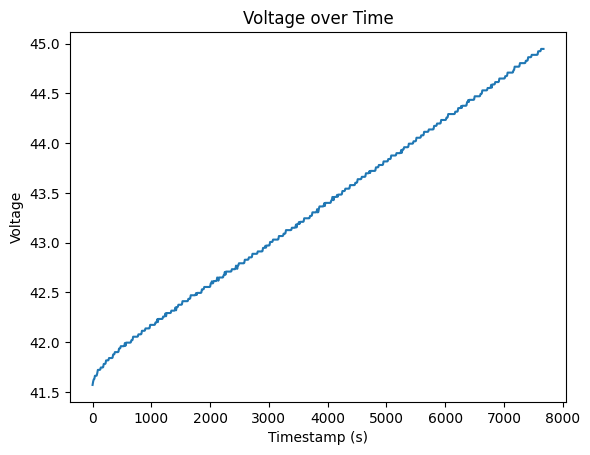

In [19]:
# Plot voltage over time
volt_data = car_data[:, idx_volt]
timestamp_data = car_data[:, idx_timestamp]
plt.plot(timestamp_data, volt_data)
plt.xlabel("Timestamp (s)")
plt.ylabel("Voltage")
plt.title("Voltage over Time")
plt.show()

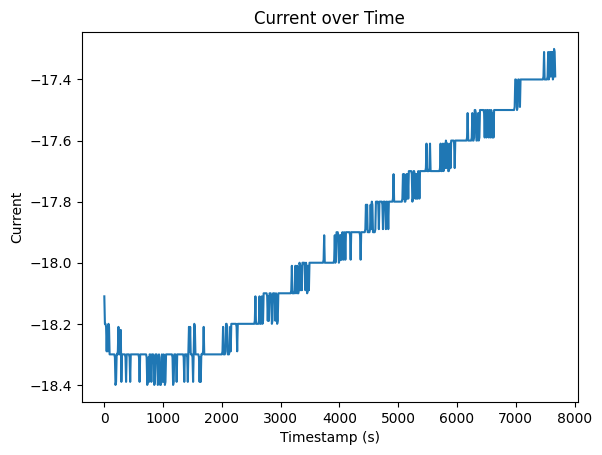

In [20]:
# Plot current over time
current_data = car_data[:, idx_current]
plt.plot(timestamp_data, current_data)
plt.xlabel("Timestamp (s)")
plt.ylabel("Current")
plt.title("Current over Time")
plt.show()

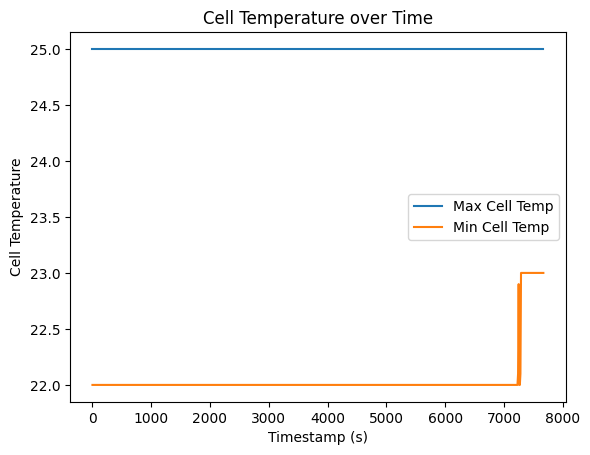

In [21]:
# Plot cell temperature over time
max_temp_data = car_data[:, idx_max_cell_temp]
min_temp_data = car_data[:, idx_min_cell_temp]
plt.plot(timestamp_data, max_temp_data, label="Max Cell Temp")
plt.plot(timestamp_data, min_temp_data, label="Min Cell Temp")
plt.xlabel("Timestamp (s)")
plt.ylabel("Cell Temperature")
plt.title("Cell Temperature over Time")
plt.legend()
plt.show()

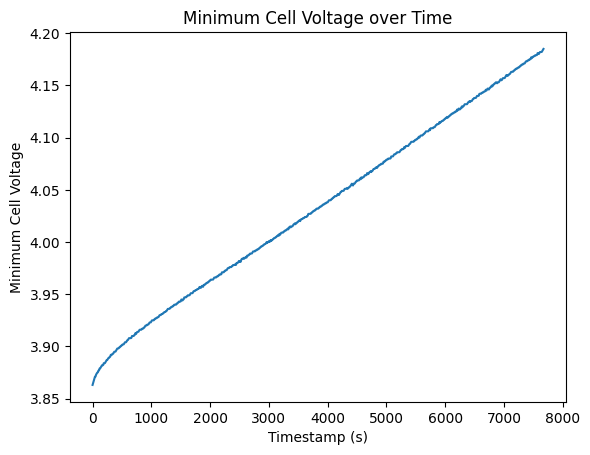

In [22]:
# Plot minimum cell voltage over time
min_cell_volt_data = car_data[:, idx_min_cell_volt]
plt.plot(timestamp_data, min_cell_volt_data)
plt.xlabel("Timestamp (s)")
plt.ylabel("Minimum Cell Voltage")
plt.title("Minimum Cell Voltage over Time")
plt.show()

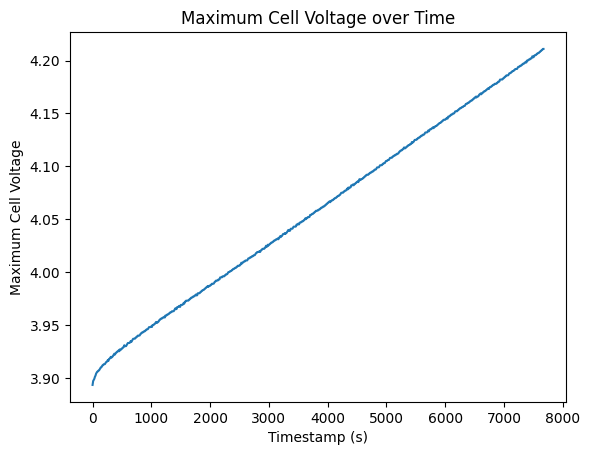

In [23]:
# Plot maximum cell voltage over time
max_cell_volt_data = car_data[:, idx_max_cell_volt]
plt.plot(timestamp_data, max_cell_volt_data)
plt.xlabel("Timestamp (s)")
plt.ylabel("Maximum Cell Voltage")
plt.title("Maximum Cell Voltage over Time")
plt.show()

In [28]:
car_data_list = []
for file in tqdm(files):
    car_data_list.append(torch.load(file))

100%|██████████| 7124/7124 [00:01<00:00, 5445.61it/s]


100%|██████████| 7124/7124 [00:02<00:00, 2616.06it/s]


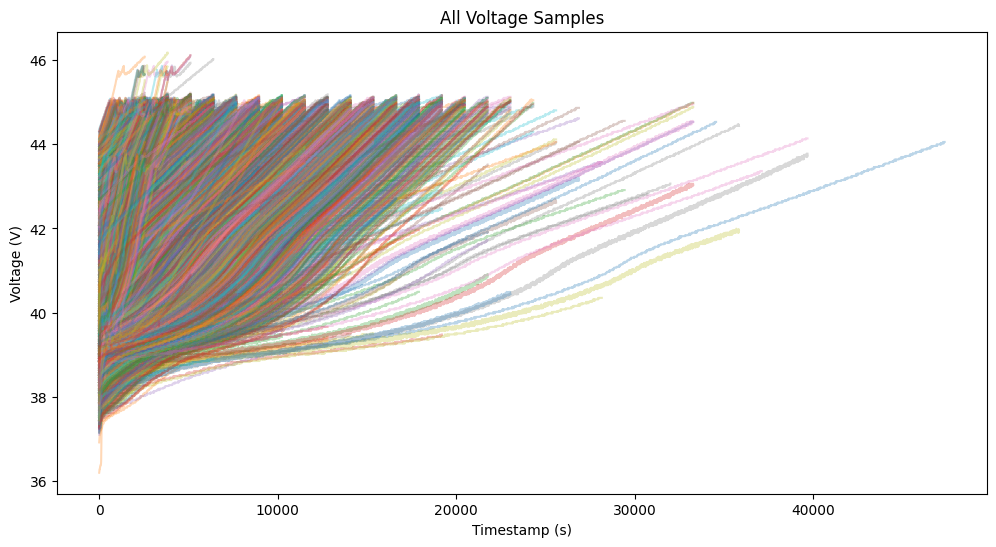

In [29]:
# Plot all voltage samples
plt.figure(figsize=(12, 6))
for car_data, car_meta_data in tqdm(car_data_list):
    volt_data = car_data[:, idx_volt]
    timestamp_data = car_data[:, idx_timestamp]
    plt.plot(timestamp_data, volt_data, alpha=0.3)
plt.xlabel("Timestamp (s)")
plt.ylabel("Voltage (V)")
plt.title("All Voltage Samples")
plt.show()

100%|██████████| 7124/7124 [00:02<00:00, 2646.61it/s]


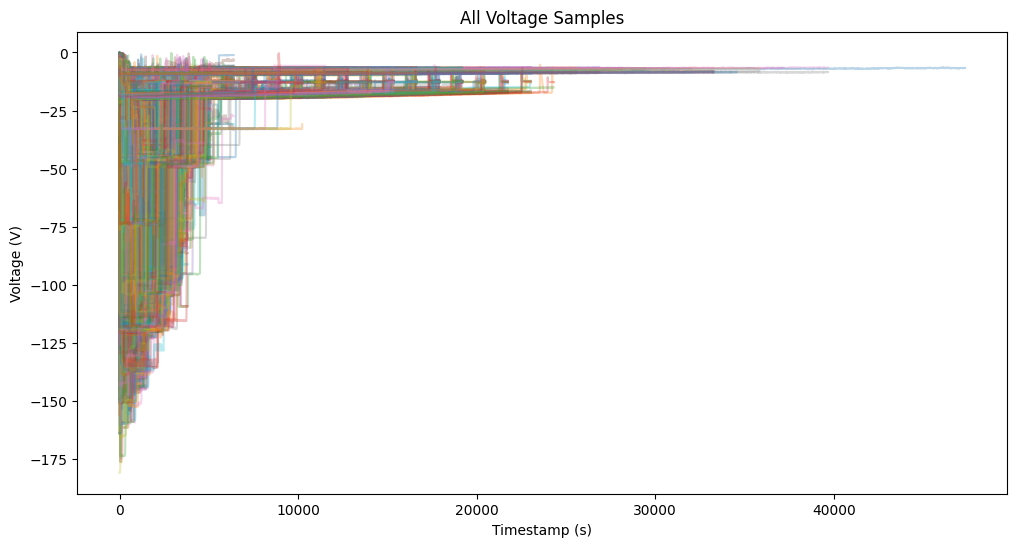

In [30]:
# Plot all current samples
plt.figure(figsize=(12, 6))
for car_data, car_meta_data in tqdm(car_data_list):
    current_data = car_data[:, idx_current]
    timestamp_data = car_data[:, idx_timestamp]
    plt.plot(timestamp_data, current_data, alpha=0.3)
plt.xlabel("Timestamp (s)")
plt.ylabel("Voltage (V)")
plt.title("All Voltage Samples")
plt.show()

100%|██████████| 7124/7124 [00:05<00:00, 1422.13it/s]


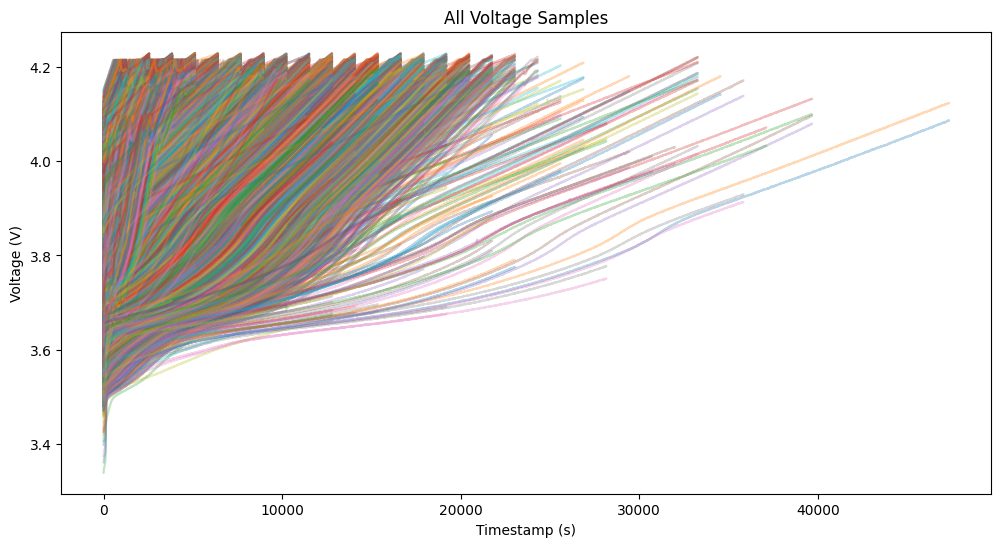

In [31]:
# Plot min, max cell voltage samples
plt.figure(figsize=(12, 6))
for car_data, car_meta_data in tqdm(car_data_list):
    min_cell_volt_data = car_data[:, idx_min_cell_volt]
    max_cell_volt_data = car_data[:, idx_max_cell_volt]
    timestamp_data = car_data[:, idx_timestamp]
    plt.plot(timestamp_data, min_cell_volt_data, alpha=0.3)
    plt.plot(timestamp_data, max_cell_volt_data, alpha=0.3)
plt.xlabel("Timestamp (s)")
plt.ylabel("Voltage (V)")
plt.title("All Voltage Samples")
plt.show()

100%|██████████| 7124/7124 [00:05<00:00, 1366.94it/s]


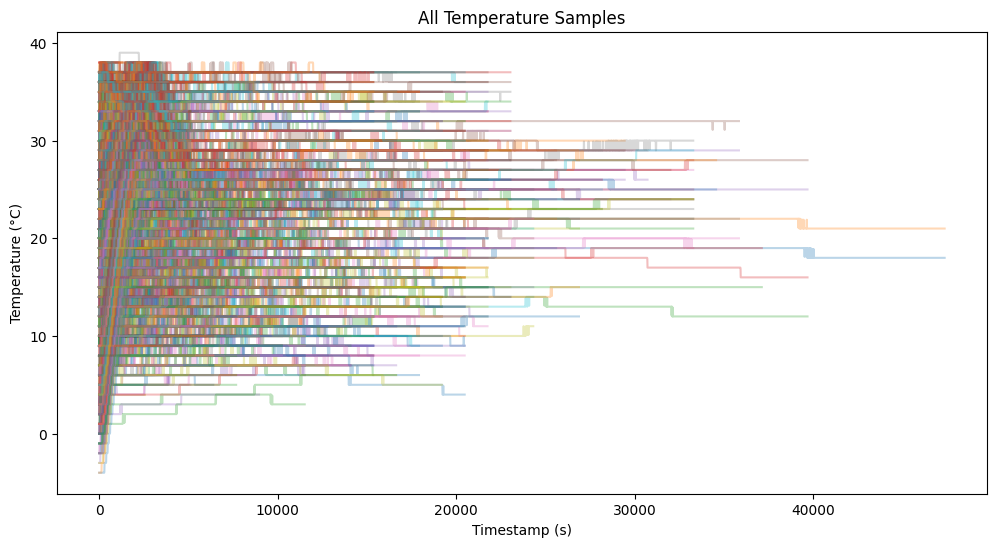

In [32]:
# Plot min, max cel temperature samples
plt.figure(figsize=(12, 6))
for car_data, car_meta_data in tqdm(car_data_list):
    min_cell_temp_data = car_data[:, idx_min_cell_temp]
    max_cell_temp_data = car_data[:, idx_max_cell_temp]
    timestamp_data = car_data[:, idx_timestamp]
    plt.plot(timestamp_data, min_cell_temp_data, alpha=0.3)
    plt.plot(timestamp_data, max_cell_temp_data, alpha=0.3)
plt.xlabel("Timestamp (s)")
plt.ylabel("Temperature (°C)")
plt.title("All Temperature Samples")
plt.show()

{768, 1152, 1664, 1920, 1024, 640, 384, 256, 2048, 1280, 128, 512, 4736, 896, 1408, 1536, 1792, 2176, 2304, 2432, 2560, 2688, 2816, 2944, 3072, 3200, 3328, 3456, 3584, 3712, 3968}


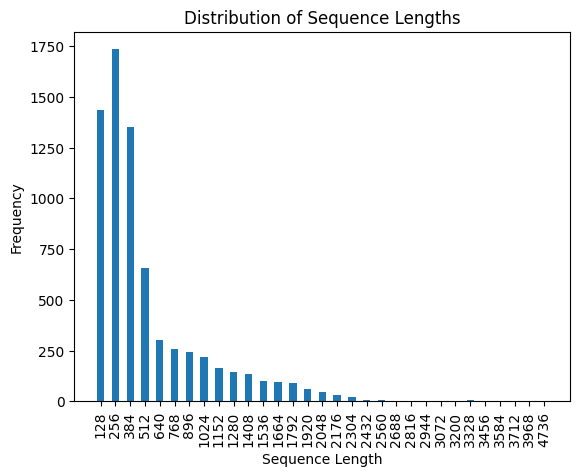

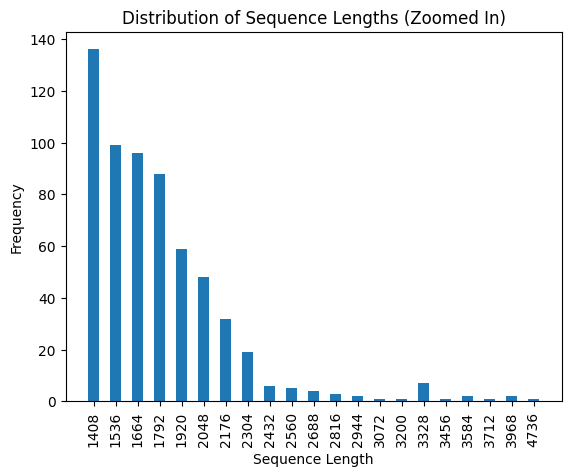

In [65]:
# Consider each time stamp as a token in NLP, let 's plot the distribution of sequence lengths
sequence_lengths = [car_data.shape[0] for car_data, car_meta_data in car_data_list]
print(set(sequence_lengths))
counts = {}
for length in sequence_lengths:
    counts[length] = counts.get(length, 0) + 1
lengths = list(counts.keys())
lengths.sort()
lengths = [str(length) for length in lengths]
frequencies = [counts[int(length)] for length in lengths]
plt.bar(lengths, frequencies, width=0.5)
plt.xlabel("Sequence Length")
plt.xticks(lengths, rotation=90)
plt.ylabel("Frequency")
plt.title("Distribution of Sequence Lengths")
plt.show()
plt.bar(lengths[10:], frequencies[10:], width=0.5)
plt.xlabel("Sequence Length")
plt.xticks(lengths[10:], rotation=90)
plt.ylabel("Frequency")
plt.title("Distribution of Sequence Lengths (Zoomed In)")
plt.show()